# Green Floor Segmentation - YUV422 Format
Detect green floor directly in YUV format (drone-native).
Design for C implementation on Bebop autopilot.

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

# Install ipywidgets for sliders
import subprocess
import sys

try:
    import ipywidgets
except ImportError:
    print("Installing ipywidgets...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])
    import ipywidgets

print("✓ ipywidgets ready")

✓ ipywidgets ready


In [15]:
# Load images from frontcam_images_test folder
image_dir = Path("./frontcam_images_test")
image_files = sorted(list(image_dir.glob("*.jpg")))

print(f"Found {len(image_files)} images")
for i, f in enumerate(image_files[:5]):
    print(f"  {i}: {f.name}")

Found 12 images
  0: 47281783.jpg
  1: 47848453.jpg
  2: 49215131.jpg
  3: 50181750.jpg
  4: 51481742.jpg


Image shape after rotation: (240, 520, 3)
YUV range: Y=[0-255], U=[0-255], V=[0-255]


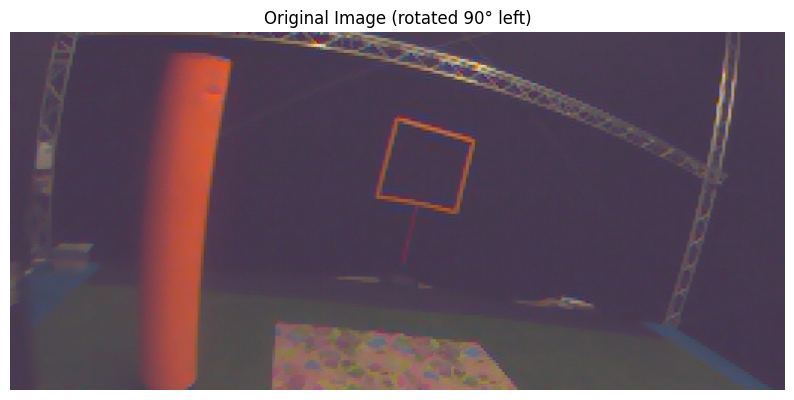

In [3]:
# Load and rotate first image
img_bgr = cv2.imread(str(image_files[0]))

# Rotate 90 degrees counter-clockwise (left) to match drone orientation
img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)

# Convert BGR to YUV
img_yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Image shape after rotation: {img_bgr.shape}")
print(f"YUV range: Y=[0-255], U=[0-255], V=[0-255]")

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title("Original Image (rotated 90° left)")
plt.axis('off')
plt.show()

Y (brightness): min=38, max=227, mean=74
U (blue-yellow): min=63, max=159, mean=131
V (red-cyan): min=103, max=226, mean=138


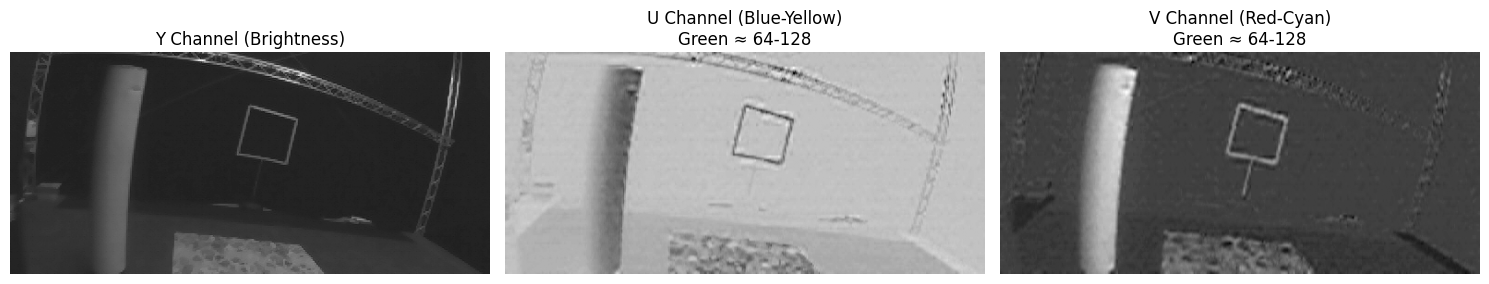

In [4]:
# Split YUV channels
Y, U, V = cv2.split(img_yuv)

print(f"Y (brightness): min={Y.min()}, max={Y.max()}, mean={Y.mean():.0f}")
print(f"U (blue-yellow): min={U.min()}, max={U.max()}, mean={U.mean():.0f}")
print(f"V (red-cyan): min={V.min()}, max={V.max()}, mean={V.mean():.0f}")

# Visualize YUV channels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(Y, cmap='gray')
axes[0].set_title("Y Channel (Brightness)")
axes[0].axis('off')

axes[1].imshow(U, cmap='gray')
axes[1].set_title("U Channel (Blue-Yellow)\nGreen ≈ 64-128")
axes[1].axis('off')

axes[2].imshow(V, cmap='gray')
axes[2].set_title("V Channel (Red-Cyan)\nGreen ≈ 64-128")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Look for best U & V values

In [9]:
from ipywidgets import IntSlider, interact

# Load first image for tuning
img_bgr = cv2.imread(str(image_files[0]))
img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)

def tune_thresholds(u_min, u_max, v_min, v_max):
    """Interactive function to update mask based on slider values"""
    Y, U, V = cv2.split(img_yuv)
    
    # Green detection
    green_mask = cv2.inRange(U, u_min, u_max) & cv2.inRange(V, v_min, v_max)
    
    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Calculate coverage
    green_pct = (cv2.countNonZero(green_mask) / green_mask.size) * 100
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(green_mask, cmap='gray')
    axes[1].set_title(f"Green Mask ({green_pct:.1f}% coverage)")
    axes[1].axis('off')
    
    # Overlay
    overlay = img_rgb.copy()
    overlay[green_mask == 0] = [255, 0, 0]
    axes[2].imshow(overlay)
    axes[2].set_title("Green Areas (white)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Thresholds: U=[{u_min}, {u_max}], V=[{v_min}, {v_max}]")
    print(f"  Green coverage: {green_pct:.1f}%")
    print(f"\nFor C code:")
    print(f"  uint8_t u_min = {u_min}, u_max = {u_max};")
    print(f"  uint8_t v_min = {v_min}, v_max = {v_max};")

# Create interactive sliders
interact(tune_thresholds,
         u_min=IntSlider(min=0, max=255, value=80, step=5, description='U min:'),
         u_max=IntSlider(min=0, max=255, value=140, step=5, description='U max:'),
         v_min=IntSlider(min=0, max=255, value=80, step=5, description='V min:'),
         v_max=IntSlider(min=0, max=255, value=140, step=5, description='V max:'))

interactive(children=(IntSlider(value=80, description='U min:', max=255, step=5), IntSlider(value=140, descrip…

<function __main__.tune_thresholds(u_min, u_max, v_min, v_max)>

In [10]:
# TUNE THESE VALUES if needed
# For green: U and V should both be near 128 (neutral)
# Adjust ranges below and re-run cell above

u_min = 110
u_max = 130
v_min = 80
v_max = 130

print(f"Current thresholds:")
print(f"  U: [{u_min}, {u_max}]")
print(f"  V: [{v_min}, {v_max}]")
print(f"\nFor C implementation, use:")
print(f"  uint8_t u_min = {u_min}, u_max = {u_max};")
print(f"  uint8_t v_min = {v_min}, v_max = {v_max};")

Current thresholds:
  U: [110, 130]
  V: [80, 130]

For C implementation, use:
  uint8_t u_min = 110, u_max = 130;
  uint8_t v_min = 80, v_max = 130;


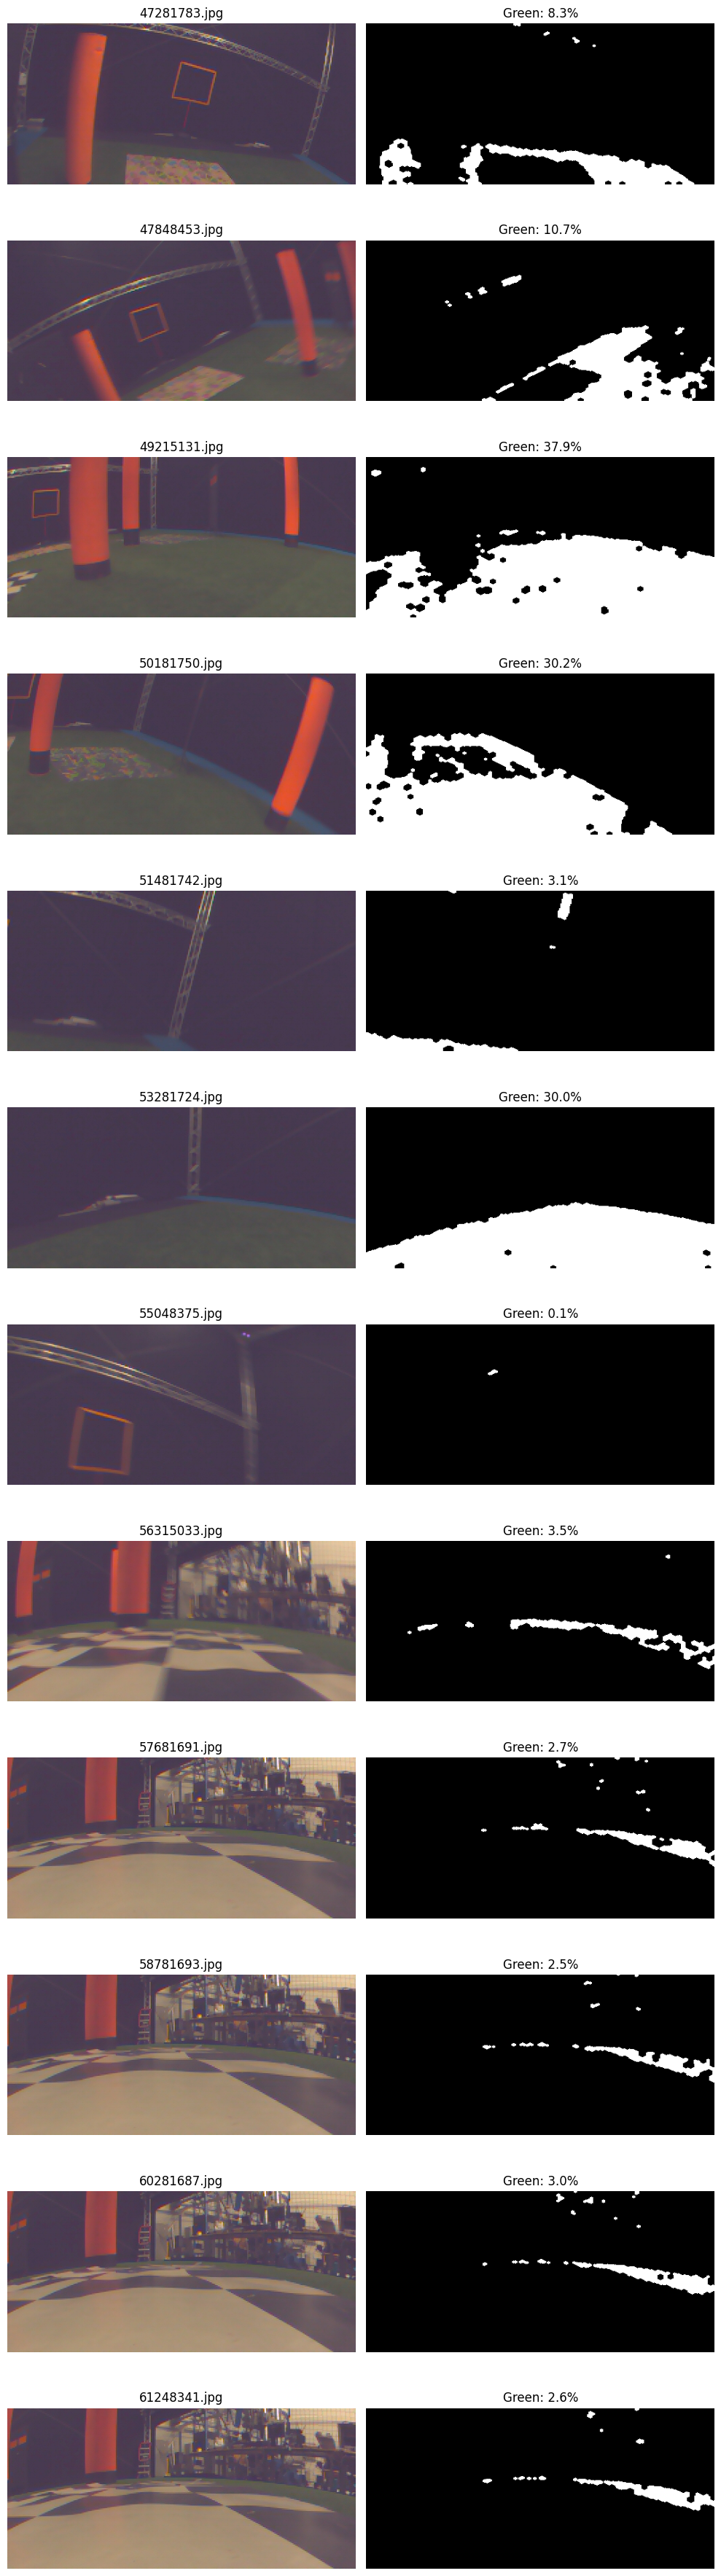

✓ All images processed with YUV detection


In [11]:
# Test on all images with rotation and YUV conversion
fig, axes = plt.subplots(len(image_files), 2, figsize=(10, 3*len(image_files)))

for idx, img_path in enumerate(image_files):
    # Load and rotate
    img_bgr = cv2.imread(str(img_path))
    img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Convert to YUV
    img_yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
    Y, U, V = cv2.split(img_yuv)
    
    # Green detection
    green_mask = cv2.inRange(U, u_min, u_max) & cv2.inRange(V, v_min, v_max)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(img_path.name)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(green_mask, cmap='gray')
    green_pct = (cv2.countNonZero(green_mask) / green_mask.size) * 100
    axes[idx, 1].set_title(f"Green: {green_pct:.1f}%")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ All images processed with YUV detection")